# Forecasting Regional PSI in Singapore

**Question:** Can we predict tomorrow's 24-hour PSI as a numeric value for Singapore's North, South, East, West and Central regions, using today's air quality, weather and fire activity in Sumatra and Borneo?

**Why it matters:** Regional forecasts can show where air quality may be worst, giving hospitals, schools and the public more useful information than a single island-wide unhealthy/not-unhealthy label.

**Data:** NEA 24-hour PSI by region (data.gov.sg) · daily weather (Open-Meteo / ERA5) · NASA FIRMS VIIRS fire hotspots

Run the four scripts in `src/` first (see README), then run this notebook top to bottom. The notebook evaluates regional regression models and saves the next-day forecast to `data/processed/regional_psi_forecast.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed"
FIGS = ROOT / "figures"; FIGS.mkdir(exist_ok=True)
THRESHOLD = 100
PSI_REGIONS = ["north", "south", "east", "west", "central"]

# Simple, consistent chart style
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a8a"
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e6", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})

df = pd.read_csv(DATA / "model_table.csv", parse_dates=["date"])
pts = pd.read_csv(DATA / "hotspots_points.csv", parse_dates=["date"])
print(f"{len(df):,} days from {df.date.min():%d %b %Y} to {df.date.max():%d %b %Y}")
print(f"Unhealthy days (overall PSI > {THRESHOLD}): {(df.psi_max > THRESHOLD).sum()}")
df.tail()

2,838 days from 01 Jan 2019 to 08 Oct 2026
Unhealthy days (overall PSI > 100): 35


,date,psi_max,psi_mean,psi_north,psi_south,psi_east,psi_west,psi_central,pm25_24h_max,n_readings,...,borneo_fires_x_wind,rain_3d,month,psi_tomorrow,psi_north_tomorrow,psi_south_tomorrow,psi_east_tomorrow,psi_west_tomorrow,psi_central_tomorrow,unhealthy_tomorrow
2833,2026-10-04,103.0,98.875000,79.0,83.0,94.0,89.0,103.0,57.0,24,...,0.000000,6.5,10,134.0,106.0,104.0,112.0,127.0,134.0,1.0
2834,2026-10-05,134.0,116.041667,106.0,104.0,112.0,127.0,134.0,87.0,24,...,9.289336,5.5,10,136.0,111.0,103.0,119.0,125.0,136.0,1.0
2835,2026-10-06,136.0,131.916667,111.0,103.0,119.0,125.0,136.0,89.0,24,...,9.453914,2.9,10,150.0,109.0,120.0,132.0,150.0,144.0,1.0
2836,2026-10-07,150.0,134.250000,109.0,120.0,132.0,150.0,144.0,103.0,24,...,9.555135,3.7,10,162.0,114.0,124.0,133.0,162.0,148.0,1.0
2837,2026-10-08,162.0,152.208333,114.0,124.0,133.0,162.0,148.0,114.0,24,...,9.434603,4.2,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. How often does Singapore get unhealthy haze?

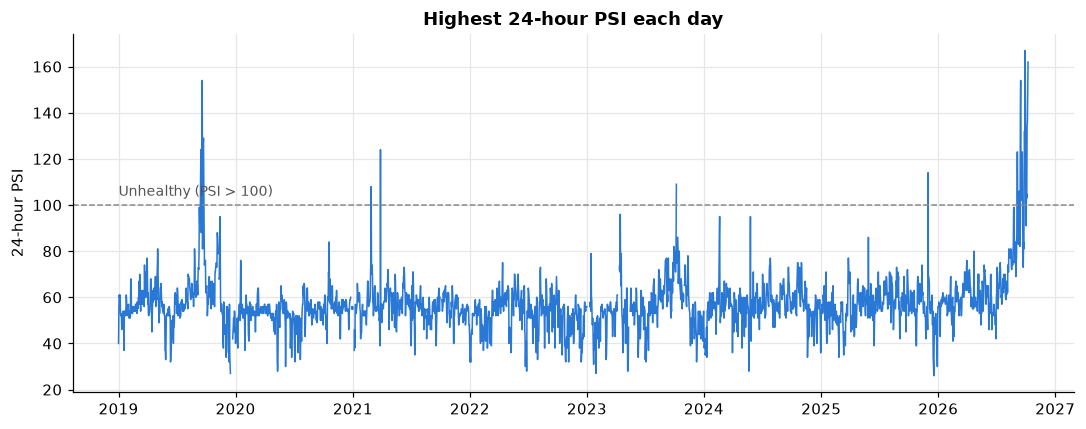

Unhealthy days per year:
year
2019     9
2020     0
2021     2
2022     0
2023     1
2024     0
2025     1
2026    22


In [2]:
fig, ax = plt.subplots()
ax.plot(df.date, df.psi_max, color=BLUE, linewidth=1)
ax.axhline(THRESHOLD, color=GREY, linestyle="--", linewidth=1)
ax.text(df.date.min(), THRESHOLD + 4, "Unhealthy (PSI > 100)", color="#555555", fontsize=9)
ax.set_title("Highest 24-hour PSI each day")
ax.set_ylabel("24-hour PSI")
fig.tight_layout(); fig.savefig(FIGS / "psi_timeline.png", bbox_inches="tight")
plt.show()

per_year = (df.assign(year=df.date.dt.year)
              .groupby("year").apply(lambda g: (g.psi_max > THRESHOLD).sum(), include_groups=False))
print("Unhealthy days per year:")
print(per_year.to_string())

**Observations:** Daily PSI is usually around 40–70, with brief spikes above the unhealthy threshold of 100. The unhealthy days cluster in a few episodes rather than following a steady pattern: the chart and yearly counts show 9 unhealthy days in 2019, only 0–2 per year from 2020 to 2025, and 22 in 2026 so far. The 2019 peak was about 155 PSI; the 2026 peak has risen to about 167 PSI, the highest in this series.

This makes haze prediction challenging because severe days are rare and concentrated in episodes, so a model has relatively few examples to learn from. PSI can also rise sharply from its usual range, while the timing and severity vary between episodes. The chart shows when air quality worsened, but not the changing combination of fire activity, wind direction, rainfall and atmospheric conditions that determines whether smoke reaches Singapore.

## 2. Do more fires mean worse air the next day?

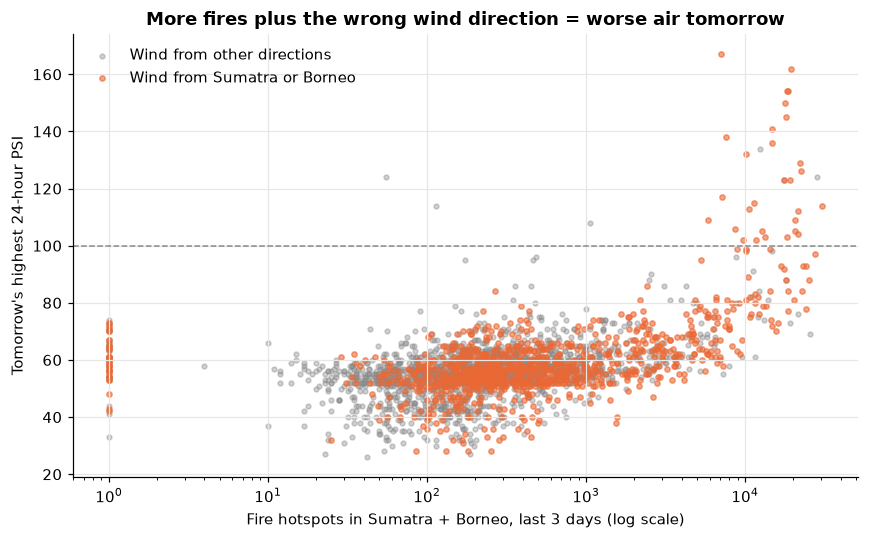

Correlation (log fires vs tomorrow's PSI): 0.45


In [3]:
d = df.dropna(subset=["psi_tomorrow", "wind_dir"]).copy()
d["fires_3d"] = d.hotspots_sumatra_3d.fillna(0) + d.hotspots_borneo_3d.fillna(0)
towards_sg = (d.wind_from_sumatra == 1) | (d.wind_from_borneo == 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(d.loc[~towards_sg, "fires_3d"] + 1, d.loc[~towards_sg, "psi_tomorrow"],
           s=10, alpha=0.4, color=GREY, label="Wind from other directions")
ax.scatter(d.loc[towards_sg, "fires_3d"] + 1, d.loc[towards_sg, "psi_tomorrow"],
           s=12, alpha=0.6, color=ORANGE, label="Wind from Sumatra or Borneo")
ax.axhline(THRESHOLD, color=GREY, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Fire hotspots in Sumatra + Borneo, last 3 days (log scale)")
ax.set_ylabel("Tomorrow's highest 24-hour PSI")
ax.set_title("More fires plus the wrong wind direction = worse air tomorrow")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIGS / "fires_vs_psi.png", bbox_inches="tight")
plt.show()

print("Correlation (log fires vs tomorrow's PSI):",
      round(np.corrcoef(np.log1p(d.fires_3d), d.psi_tomorrow)[0, 1], 2))

**Observations:** The scatter plot trends upward: days with more Sumatra and Borneo hotspots in the preceding three days tend to have higher next-day PSI. The relationship is not deterministic, though; there is wide spread at similar hotspot counts, and some high-PSI days occur with winds from other directions. The correlation between log hotspot counts and next-day PSI is **0.45**, a moderate positive association rather than a strong standalone predictor.

This suggests fire activity is a useful warning signal, especially when winds can carry smoke toward Singapore, but hotspot counts alone do not explain next-day air quality. Wind, weather, the location of fires and other atmospheric conditions also matter; the correlation does not establish that fires alone caused the observed PSI.

## 3. Which wind directions bring haze?
Looking only at the dry season (August to October), when fires are most common.

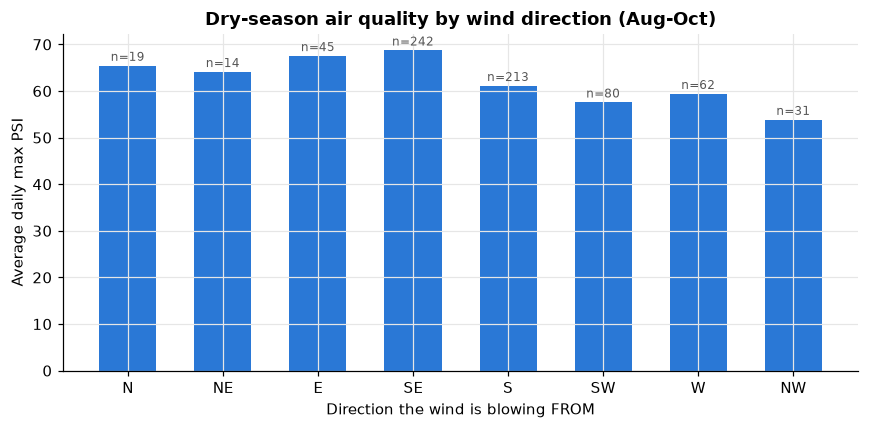

,mean_psi,days
wind_sector,,
N,65.473684,19
NE,64.142857,14
E,67.555556,45
SE,68.760331,242
S,61.140845,213
SW,57.600000,80
W,59.435484,62
NW,53.870968,31


In [4]:
dry = df[df.date.dt.month.isin([8, 9, 10])].dropna(subset=["wind_dir", "psi_max"]).copy()
sectors = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
dry["wind_sector"] = pd.Categorical(
    [sectors[int(((w + 22.5) % 360) // 45)] for w in dry.wind_dir], categories=sectors)
summary = dry.groupby("wind_sector", observed=False).agg(
    mean_psi=("psi_max", "mean"), days=("psi_max", "size"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary.index.astype(str), summary.mean_psi, color=BLUE, width=0.6)
for i, (v, n) in enumerate(zip(summary.mean_psi, summary.days)):
    if n > 0:
        ax.text(i, v + 1, f"n={n}", ha="center", fontsize=8, color="#555555")
ax.set_xlabel("Direction the wind is blowing FROM")
ax.set_ylabel("Average daily max PSI")
ax.set_title("Dry-season air quality by wind direction (Aug-Oct)")
fig.tight_layout(); fig.savefig(FIGS / "psi_by_wind.png", bbox_inches="tight")
plt.show()
summary

**Observations:** In the August–October sample, average daily maximum PSI is highest with winds from the **southeast (68.8; 242 days)** and **east (67.6; 45 days)**. It is lower for south-westerly (57.6; 80 days) and north-westerly winds (53.9; 31 days). The bars are averages, not proof that wind direction alone determines haze; the number of days differs considerably by sector, and the analysis combines multiple years and other conditions. The pattern is consistent with wind direction being one factor that affects whether regional smoke reaches Singapore.

## 4. Where were the fires on the worst haze day?

Worst day: 29 Sep 2026 (PSI 167); 7,648 hotspots in the 3 days before


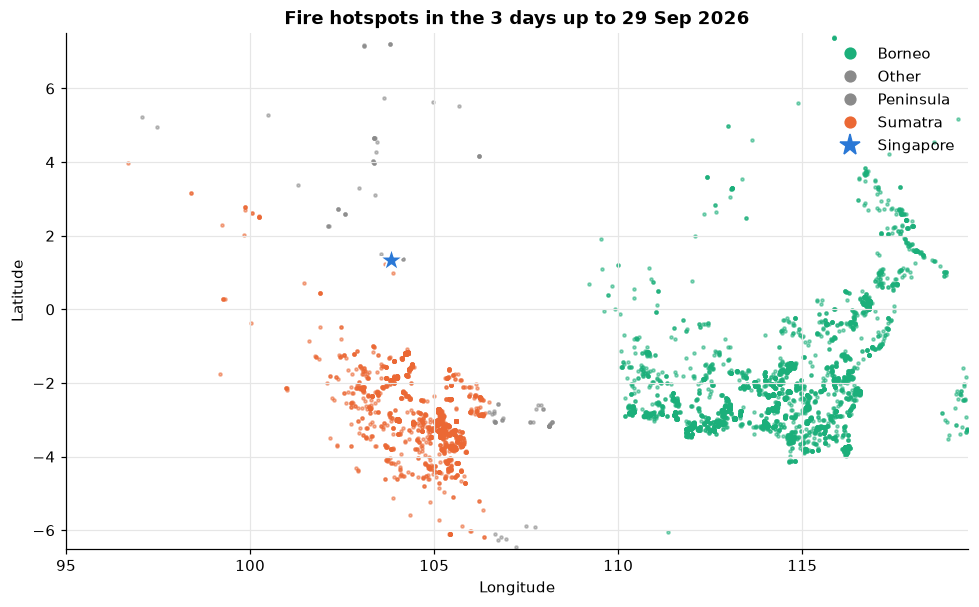

In [2]:
worst_day = df.loc[df.psi_max.idxmax(), "date"]
window = pts[(pts.date > worst_day - pd.Timedelta(days=3)) & (pts.date <= worst_day)]
print(f"Worst day: {worst_day:%d %b %Y} (PSI {df.psi_max.max():.0f}); "
      f"{len(window):,} hotspots in the 3 days before")

colors = {"sumatra": ORANGE, "borneo": GREEN, "peninsula": GREY, "other": GREY}
fig, ax = plt.subplots(figsize=(9, 6))
from matplotlib.lines import Line2D
handles = []
for region, g in window.groupby("region"):
    ax.scatter(g.longitude, g.latitude, s=4, alpha=0.5, color=colors.get(region, GREY))
    handles.append(Line2D([], [], marker="o", linestyle="", markersize=7,
                          color=colors.get(region, GREY), label=region.title()))
ax.scatter(103.82, 1.35, marker="*", s=250, color=BLUE, edgecolor="white", zorder=5)
handles.append(Line2D([], [], marker="*", linestyle="", markersize=14, color=BLUE, label="Singapore"))
ax.set_xlim(95, 119.5); ax.set_ylim(-6.5, 7.5)
ax.set_aspect("equal")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Fire hotspots in the 3 days up to {worst_day:%d %b %Y}")
ax.legend(handles=handles, frameon=False, loc="upper right")
fig.tight_layout(); fig.savefig(FIGS / "hotspot_map.png", bbox_inches="tight")
plt.show()

**Observations:** The worst recorded day in this dataset is **29 September 2026**, when the overall PSI reached **167**. The map shows **7,648 detected hotspots** across Sumatra and Borneo in the preceding three days, with visible clusters in both areas. This gives geographic context for the haze episode, but hotspot proximity alone cannot show which fires contributed most to Singapore's air; wind direction and smoke transport determine whether emissions reach the island.

*Optional upgrade:* add a coastline basemap with `geopandas` + Natural Earth country boundaries, or `contextily` for map tiles.

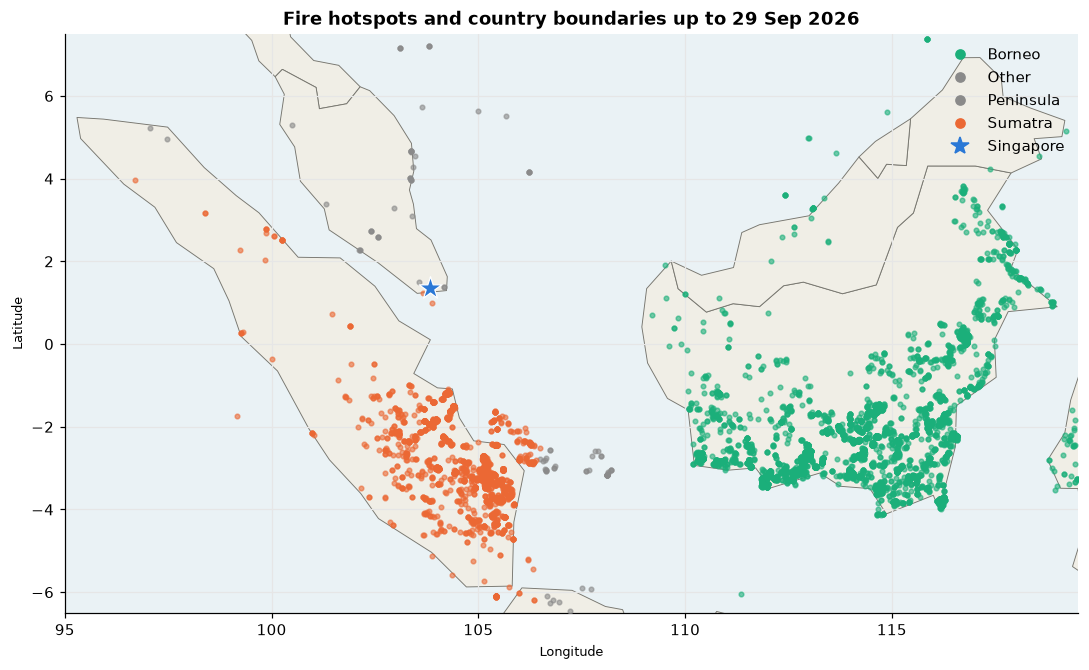

In [3]:
import geopandas as gpd
from matplotlib.lines import Line2D

# Natural Earth 1:110m country boundaries (downloaded from the Natural Earth public dataset).
NATURAL_EARTH_URL = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_0_countries.zip"
)
countries = gpd.read_file(NATURAL_EARTH_URL)
map_countries = countries.cx[95.0:119.5, -6.5:7.5]

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor("#eaf2f5")
map_countries.plot(ax=ax, color="#f0eee6", edgecolor="#77766f", linewidth=0.6)

map_colors = {"sumatra": ORANGE, "borneo": GREEN, "peninsula": GREY, "other": GREY}
for hotspot_region, group in window.groupby("region"):
    ax.scatter(group.longitude, group.latitude, s=9, alpha=0.6,
               color=map_colors.get(hotspot_region, GREY), zorder=3)

ax.scatter(103.82, 1.35, marker="*", s=240, color=BLUE,
           edgecolor="white", linewidth=0.8, zorder=5)
legend_items = [
    Line2D([], [], marker="o", linestyle="", color=map_colors[name],
           markersize=6, label=name.title())
    for name in sorted(window.region.dropna().unique())
]
legend_items.append(Line2D([], [], marker="*", linestyle="", color=BLUE,
                           markersize=12, label="Singapore"))

ax.set_xlim(95, 119.5)
ax.set_ylim(-6.5, 7.5)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Fire hotspots and country boundaries up to {worst_day:%d %b %Y}")
ax.legend(handles=legend_items, frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(FIGS / "hotspot_map_basemap.png", bbox_inches="tight")
plt.show()

## 5. Regional next-day PSI prediction

Each model predicts next-day maximum 24-hour PSI for North, South, East, West, and Central. All models use the same 39 predictors from the three days before the target (t−2, t−1, and t): regional PSI, wind direction components and speed, hotspot counts by Sumatra/Borneo/Peninsula, rain, and humidity. Evaluation uses five chronological `TimeSeriesSplit` folds with a one-day purge gap.

**Models compared**
- **5a Gaussian GLM:** linear baseline with normally distributed errors.
- **5b Quadratic Gaussian model:** adds squared predictor terms to represent curved effects.
- **5c Log-transformed Gaussian model:** applies `log1p` to nonnegative predictors to reduce skew and allow nonlinear scaling.
- **5d Gaussian GAM:** fits smooth spline effects for predictors instead of assuming a straight-line effect.

### 5a. Gaussian generalized linear model

Fit a Gaussian GLM with an identity link separately for each region. Report pooled out-of-fold MSE and RMSE. Use held-out residual-versus-fitted, residual-over-time, and normal Q–Q plots to assess model assumptions.

In [9]:
# Shared setup: build predictors from the three days before each next-day PSI target.
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import probplot

PSI_REGIONS = ["north", "south", "east", "west", "central"]
TARGETS = {region: f"psi_{region}_tomorrow" for region in PSI_REGIONS}

# Retain predictors in their natural units; 5c applies log1p to nonnegative variables.
model_source = df.sort_values("date").reset_index(drop=True).copy()
DAILY_PREDICTORS = (
    [f"psi_{region}" for region in PSI_REGIONS]
    + ["wind_from_east", "wind_from_north", "wind_speed_max"]
    + ["hotspots_sumatra", "hotspots_borneo", "hotspots_peninsula"]
    + ["rain_mm", "humidity_mean"]
)
LOG_PREDICTORS = (
    [f"psi_{region}" for region in PSI_REGIONS]
    + ["wind_speed_max", "hotspots_sumatra", "hotspots_borneo",
       "hotspots_peninsula", "rain_mm", "humidity_mean"]
)

# For a target at t+1, use each predictor from t-2, t-1, and t.
FEATURES = []
LOG_FEATURES = []
for lag in (2, 1, 0):
    for predictor in DAILY_PREDICTORS:
        feature = f"{predictor}_lag{lag}"
        model_source[feature] = model_source[predictor].shift(lag)
        FEATURES.append(feature)
        if predictor in LOG_PREDICTORS:
            LOG_FEATURES.append(feature)

model_frame = model_source[["date", *FEATURES, *TARGETS.values()]].copy()
OUTER_FOLDS = 5
CV_GAP = 1
print(f"Three-day predictors: {len(FEATURES)} features across t-2, t-1, and t")
print(f"Log-transformed in 5c: {len(LOG_FEATURES)} nonnegative features")
print(f"Forecast targets: {', '.join(TARGETS.values())}")
print(f"Available dates: {model_frame.date.min():%Y-%m-%d} to {model_frame.date.max():%Y-%m-%d}")

Three-day predictors: 39 features across t-2, t-1, and t
Log-transformed in 5c: 33 nonnegative features
Forecast targets: psi_north_tomorrow, psi_south_tomorrow, psi_east_tomorrow, psi_west_tomorrow, psi_central_tomorrow
Available dates: 2019-01-01 to 2026-10-08


In [10]:
# 5a: score a Gaussian-identity GLM on the same five chronological folds used by 5b and 5c.
def make_glm():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        TweedieRegressor(power=0, link="identity", alpha=0, max_iter=2000, tol=1e-7),
    )

glm_oof_rows, glm_metric_rows = [], []
for region, target in TARGETS.items():
    region_data = model_frame.dropna(subset=[target]).sort_values("date").reset_index(drop=True)
    actual_values, predicted_values = [], []
    splitter = TimeSeriesSplit(n_splits=OUTER_FOLDS, gap=CV_GAP)

    for fold, (train_indices, test_indices) in enumerate(splitter.split(region_data), start=1):
        fold_train, fold_test = region_data.iloc[train_indices], region_data.iloc[test_indices]
        glm_model = make_glm().fit(fold_train[FEATURES], fold_train[target])
        fold_prediction = glm_model.predict(fold_test[FEATURES])
        fold_actual = fold_test[target].to_numpy()
        actual_values.extend(fold_actual)
        predicted_values.extend(fold_prediction)
        glm_oof_rows.extend({
            "region": region.title(), "fold": fold, "date": date,
            "observed_psi": observed, "predicted_psi": predicted,
            "residual": observed - predicted,
        } for date, observed, predicted in zip(fold_test.date, fold_actual, fold_prediction))

    glm_metric_rows.append({
        "region": region.title(),
        "test days": len(actual_values),
        "GLM MSE": mean_squared_error(actual_values, predicted_values),
        "GLM RMSE": np.sqrt(mean_squared_error(actual_values, predicted_values)),
    })

glm_results = pd.DataFrame(glm_metric_rows).set_index("region")
glm_oof = pd.DataFrame(glm_oof_rows)
print(f"Mean regional GLM test MSE: {glm_results['GLM MSE'].mean():.2f}")
glm_results.round(2)

Mean regional GLM test MSE: 51.99


,test days,GLM MSE,GLM RMSE
region,,,
North,2330,54.47,7.38
South,2330,46.42,6.81
East,2330,47.43,6.89
West,2330,58.06,7.62
Central,2330,53.56,7.32


**5a results:** Mean regional five-fold test MSE is **51.99 PSI²** (mean RMSE **7.20 PSI points**). The residual-versus-fitted plots show large positive outliers and changing spread; residuals over time cluster during the 2026 haze episode, and the Q–Q plots depart from normality in the upper tail. This indicates the Gaussian assumptions are imperfect and high-PSI events are underpredicted. The quadratic, log-transformed, and GAM alternatives are evaluated in 5b–5d using the same folds.

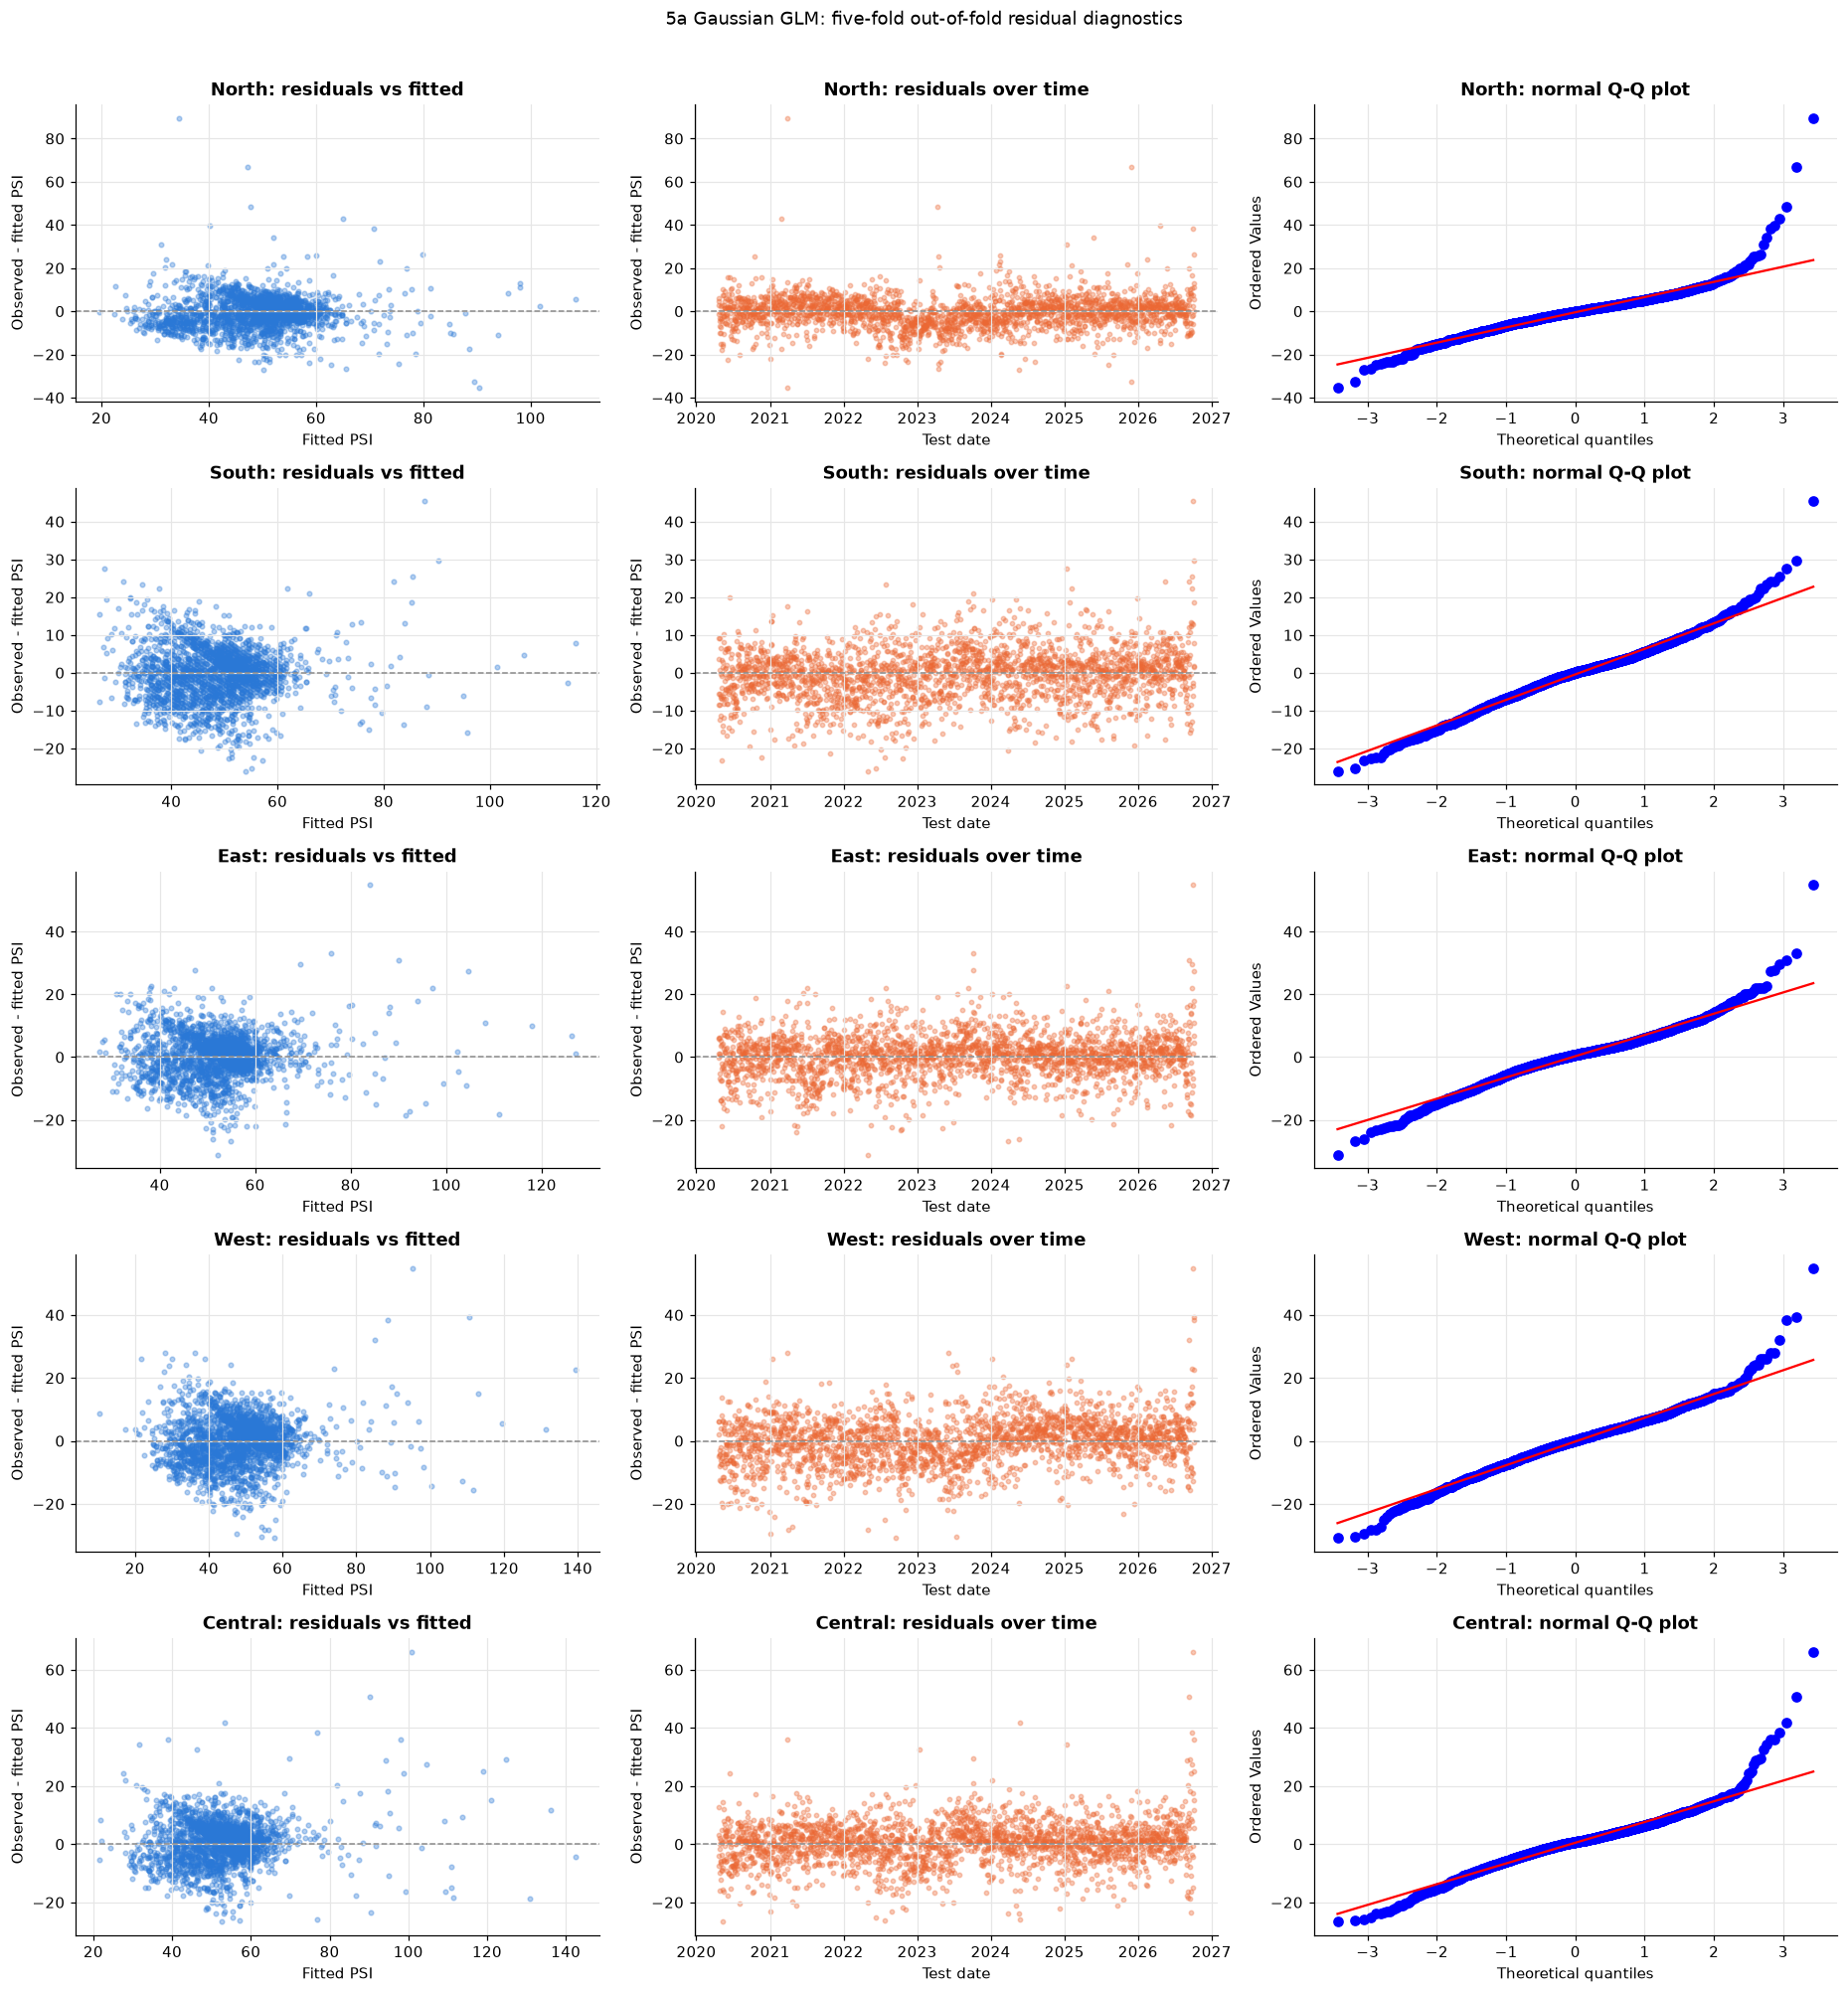

In [11]:
# 5a diagnostics: inspect held-out GLM residuals by region.
fig, axes = plt.subplots(len(PSI_REGIONS), 3, figsize=(17, 18))
for row_index, region in enumerate(PSI_REGIONS):
    region_name = region.title()
    diagnostics = glm_oof[glm_oof.region == region_name]

    # Check for curvature and changing residual spread across fitted values.
    axes[row_index, 0].scatter(
        diagnostics.predicted_psi, diagnostics.residual,
        s=9, alpha=0.35, color=BLUE,
    )
    axes[row_index, 0].axhline(0, color=GREY, linestyle="--", linewidth=1)
    axes[row_index, 0].set_title(f"{region_name}: residuals vs fitted")
    axes[row_index, 0].set_xlabel("Fitted PSI")
    axes[row_index, 0].set_ylabel("Observed - fitted PSI")

    # Check whether residuals show time-ordered runs or changing episode bias.
    axes[row_index, 1].scatter(
        diagnostics.date, diagnostics.residual,
        s=8, alpha=0.35, color=ORANGE,
    )
    axes[row_index, 1].axhline(0, color=GREY, linestyle="--", linewidth=1)
    axes[row_index, 1].set_title(f"{region_name}: residuals over time")
    axes[row_index, 1].set_xlabel("Test date")
    axes[row_index, 1].set_ylabel("Observed - fitted PSI")

    # Check whether residual quantiles follow a normal distribution.
    probplot(diagnostics.residual, dist="norm", plot=axes[row_index, 2])
    axes[row_index, 2].set_title(f"{region_name}: normal Q-Q plot")

fig.suptitle("5a Gaussian GLM: five-fold out-of-fold residual diagnostics", y=1.01)
fig.tight_layout()
fig.savefig(FIGS / "glm_residual_diagnostics.png", bbox_inches="tight")
plt.show()

**Residual diagnostics:** The residual-versus-fitted panels are generally centered around zero, but show large positive outliers and some changing spread at higher fitted PSI. The residual-over-time panels show especially large positive errors during the 2026 haze episode, meaning the Gaussian GLM underpredicts some extreme readings. The Q–Q plots bend well above the reference line in their upper tails, so residuals are not normally distributed. The Gaussian linear-model assumptions are therefore not fully satisfied; the reported cross-validated RMSE remains useful for prediction comparison, but coefficient-based inference and extreme-episode predictions should be treated cautiously.

### 5b. Quadratic Gaussian model

Extend the 5a Gaussian model with a squared term ($x^2$) for each standardized predictor. This allows each predictor to have a curved effect while retaining an additive model. Use the same five chronological test folds and compare pooled out-of-fold MSE by region.

In [13]:
# 5b: add one squared term per standardized predictor to model smooth curvature.
def add_squared_terms(values):
    return np.column_stack((values, values ** 2))


def make_quadratic_glm():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        FunctionTransformer(add_squared_terms, validate=False),
        StandardScaler(),
        TweedieRegressor(power=0, link="identity", alpha=0, max_iter=10000, tol=1e-7),
    )

quadratic_oof_rows, quadratic_metric_rows = [], []
for region, target in TARGETS.items():
    region_data = model_frame.dropna(subset=[target]).sort_values("date").reset_index(drop=True)
    actual_values, predicted_values = [], []
    splitter = TimeSeriesSplit(n_splits=OUTER_FOLDS, gap=CV_GAP)

    for fold, (train_indices, test_indices) in enumerate(splitter.split(region_data), start=1):
        fold_train, fold_test = region_data.iloc[train_indices], region_data.iloc[test_indices]
        quadratic_model = make_quadratic_glm().fit(fold_train[FEATURES], fold_train[target])
        fold_prediction = quadratic_model.predict(fold_test[FEATURES])
        fold_actual = fold_test[target].to_numpy()
        actual_values.extend(fold_actual)
        predicted_values.extend(fold_prediction)
        quadratic_oof_rows.extend({
            "region": region.title(), "fold": fold,
            "observed_psi": observed, "predicted_psi": predicted,
        } for observed, predicted in zip(fold_actual, fold_prediction))

    quadratic_metric_rows.append({
        "region": region.title(),
        "test days": len(actual_values),
        "Quadratic MSE": mean_squared_error(actual_values, predicted_values),
        "Quadratic RMSE": np.sqrt(mean_squared_error(actual_values, predicted_values)),
    })

quadratic_results = pd.DataFrame(quadratic_metric_rows).set_index("region")
quadratic_oof = pd.DataFrame(quadratic_oof_rows)
print(f"Mean regional quadratic-model test MSE: {quadratic_results['Quadratic MSE'].mean():.2f}")
quadratic_results.round(2)

Mean regional quadratic-model test MSE: 62.12


,test days,Quadratic MSE,Quadratic RMSE
region,,,
North,2330,63.13,7.95
South,2330,55.30,7.44
East,2330,58.13,7.62
West,2330,71.34,8.45
Central,2330,62.69,7.92


### 5c. Log-transformed Gaussian model

Apply `log1p(x)` to the nonnegative PSI, wind-speed, hotspot-count, rain, and humidity predictors. Keep sine/cosine wind-direction components unchanged because they can be negative. Fit the same Gaussian GLM and score it on the same five chronological folds.

In [14]:
# 5c: log-transform nonnegative predictors, then evaluate the Gaussian GLM on identical folds.
def log_transform_features(frame):
    transformed = frame.copy()
    transformed[LOG_FEATURES] = np.log1p(transformed[LOG_FEATURES].clip(lower=0))
    return transformed

log_oof_rows, log_metric_rows = [], []
for region, target in TARGETS.items():
    region_data = model_frame.dropna(subset=[target]).sort_values("date").reset_index(drop=True)
    actual_values, predicted_values = [], []
    splitter = TimeSeriesSplit(n_splits=OUTER_FOLDS, gap=CV_GAP)

    for fold, (train_indices, test_indices) in enumerate(splitter.split(region_data), start=1):
        fold_train, fold_test = region_data.iloc[train_indices], region_data.iloc[test_indices]
        x_train = log_transform_features(fold_train[FEATURES])
        x_test = log_transform_features(fold_test[FEATURES])
        log_model = make_glm().fit(x_train, fold_train[target])
        fold_prediction = log_model.predict(x_test)
        fold_actual = fold_test[target].to_numpy()
        actual_values.extend(fold_actual)
        predicted_values.extend(fold_prediction)
        log_oof_rows.extend({
            "region": region.title(), "fold": fold,
            "observed_psi": observed, "predicted_psi": predicted,
        } for observed, predicted in zip(fold_actual, fold_prediction))

    log_metric_rows.append({
        "region": region.title(),
        "test days": len(actual_values),
        "Log GLM MSE": mean_squared_error(actual_values, predicted_values),
        "Log GLM RMSE": np.sqrt(mean_squared_error(actual_values, predicted_values)),
    })

log_results = pd.DataFrame(log_metric_rows).set_index("region")
log_oof = pd.DataFrame(log_oof_rows)
print(f"Mean regional log-GLM test MSE: {log_results['Log GLM MSE'].mean():.2f}")
log_results.round(2)

Mean regional log-GLM test MSE: 62.52


,test days,Log GLM MSE,Log GLM RMSE
region,,,
North,2330,57.07,7.55
South,2330,54.85,7.41
East,2330,57.88,7.61
West,2330,74.58,8.64
Central,2330,68.21,8.26


### 5d. Gaussian generalized additive model (GAM)

Fit a separate smooth spline term for each predictor to allow flexible nonlinear effects without pairwise interactions. Use the same five chronological folds and report pooled out-of-fold MSE by region.

In [15]:
# 5d: fit a Gaussian additive spline model and score it on the same chronological folds.
from pygam import LinearGAM, s

def make_gam():
    smooth_terms = s(0, n_splines=6)
    for index in range(1, len(FEATURES)):
        smooth_terms += s(index, n_splines=6)
    return LinearGAM(smooth_terms, lam=0.6, max_iter=100)


gam_oof_rows, gam_metric_rows = [], []
for region, target in TARGETS.items():
    region_data = model_frame.dropna(subset=[target]).sort_values("date").reset_index(drop=True)
    actual_values, predicted_values = [], []
    splitter = TimeSeriesSplit(n_splits=OUTER_FOLDS, gap=CV_GAP)

    for fold, (train_indices, test_indices) in enumerate(splitter.split(region_data), start=1):
        fold_train, fold_test = region_data.iloc[train_indices], region_data.iloc[test_indices]
        imputer = SimpleImputer(strategy="median")
        x_train = imputer.fit_transform(fold_train[FEATURES])
        x_test = imputer.transform(fold_test[FEATURES])
        gam_model = make_gam().fit(x_train, fold_train[target].to_numpy())
        fold_prediction = gam_model.predict(x_test)
        fold_actual = fold_test[target].to_numpy()
        actual_values.extend(fold_actual)
        predicted_values.extend(fold_prediction)
        gam_oof_rows.extend({
            "region": region.title(), "fold": fold,
            "observed_psi": observed, "predicted_psi": predicted,
        } for observed, predicted in zip(fold_actual, fold_prediction))

    gam_metric_rows.append({
        "region": region.title(),
        "test days": len(actual_values),
        "GAM MSE": mean_squared_error(actual_values, predicted_values),
        "GAM RMSE": np.sqrt(mean_squared_error(actual_values, predicted_values)),
    })

gam_results = pd.DataFrame(gam_metric_rows).set_index("region")
gam_oof = pd.DataFrame(gam_oof_rows)

# Compare all four models using equally weighted regional pooled out-of-fold RMSE.
model_comparison = pd.DataFrame({
    "5a GLM RMSE": np.sqrt(glm_results["GLM MSE"]),
    "5b Quadratic RMSE": np.sqrt(quadratic_results["Quadratic MSE"]),
    "5c Log GLM RMSE": np.sqrt(log_results["Log GLM MSE"]),
    "5d GAM RMSE": np.sqrt(gam_results["GAM MSE"]),
})
model_summary = model_comparison.mean().to_frame("mean regional test RMSE").sort_values(
    "mean regional test RMSE"
)
best_model_name = model_summary.index[0].replace(" RMSE", "")
print("Five-fold time-series test RMSE by region:")
display(model_comparison.round(2))
print(f"Best model by mean regional test RMSE: {best_model_name}")
model_summary.round(2)

Five-fold time-series test RMSE by region:


,5a GLM RMSE,5b Quadratic RMSE,5c Log GLM RMSE,5d GAM RMSE
region,,,,
North,7.38,7.95,7.55,7.45
South,6.81,7.44,7.41,7.03
East,6.89,7.62,7.61,7.15
West,7.62,8.45,8.64,7.96
Central,7.32,7.92,8.26,7.58


Best model by mean regional test RMSE: 5a GLM


,mean regional test RMSE
5a GLM RMSE,7.20
5d GAM RMSE,7.43
5b Quadratic RMSE,7.87
5c Log GLM RMSE,7.89


### Comparing 5a, 5b, 5c, and 5d

All four models use the same three-day predictors and five chronological test folds. The table reports pooled out-of-fold RMSE by region; the summary equally weights the five regional RMSEs. **5a Gaussian GLM has the lowest mean regional RMSE (7.20 PSI points)**, followed by **5d GAM (7.43)**, **5b quadratic Gaussian model (7.87)**, and **5c log-transformed Gaussian model (7.89)**. The log transform and quadratic expansion did not improve accuracy here; the GAM was closer to the GLM but still had higher error. Despite its residual-assumption issues, 5a is the best model by the requested test-RMSE criterion. Extreme-haze errors remain uncertain across all models.

## 6. Next-day regional PSI forecast

Refit all four models on labeled data. Use the model with the lowest mean regional five-fold RMSE as the primary forecast, and include estimates from all four methods for comparison.

In [25]:
# Part 6: refit all four models on labeled data and predict the next day.
latest = model_frame.sort_values("date").tail(1)
forecast_date = latest.date.iloc[0] + pd.Timedelta(days=1)
forecast_rows = []
final_models = {name: {} for name in (
    "5a GLM", "5b Quadratic", "5c Log GLM", "5d GAM"
)}

for region, target in TARGETS.items():
    history = model_frame.dropna(subset=[target]).sort_values("date")
    x_train, y_train = history[FEATURES], history[target].to_numpy()
    x_latest = latest[FEATURES]

    final_models["5a GLM"][region] = make_glm().fit(x_train, y_train)
    final_models["5b Quadratic"][region] = make_quadratic_glm().fit(x_train, y_train)
    final_models["5c Log GLM"][region] = make_glm().fit(
        log_transform_features(x_train), y_train
    )
    imputer = SimpleImputer(strategy="median")
    final_x = imputer.fit_transform(x_train)
    final_models["5d GAM"][region] = (imputer, make_gam().fit(final_x, y_train))

    model_predictions = {
        "5a GLM": final_models["5a GLM"][region].predict(x_latest)[0],
        "5b Quadratic": final_models["5b Quadratic"][region].predict(x_latest)[0],
        "5c Log GLM": final_models["5c Log GLM"][region].predict(
            log_transform_features(x_latest)
        )[0],
        "5d GAM": final_models["5d GAM"][region][1].predict(
            final_models["5d GAM"][region][0].transform(x_latest)
        )[0],
    }
    forecast_rows.append({
        "forecast_date": forecast_date.date().isoformat(),
        "region": region.title(),
        "selected_model": best_model_name,
        "predicted_psi": round(float(model_predictions[best_model_name]), 1),
        **{f"{name}_psi": round(float(value), 1)
           for name, value in model_predictions.items()},
    })

forecast = pd.DataFrame(forecast_rows)
forecast.to_csv(DATA / "regional_psi_forecast.csv", index=False)
print(f"Selected model by five-fold test RMSE: {best_model_name}")
print(f"Forecast date: {forecast_date:%d %b %Y}")
forecast

Selected model by five-fold test RMSE: 5a GLM
Forecast date: 09 Oct 2026


,forecast_date,region,selected_model,predicted_psi,5a GLM_psi,5b Quadratic_psi,5c Log GLM_psi,5d GAM_psi
0,2026-10-09,North,5a GLM,107.9,107.9,115.1,87.5,105.5
1,2026-10-09,South,5a GLM,111.3,111.3,107.4,90.7,105.1
2,2026-10-09,East,5a GLM,121.2,121.2,118.6,97.2,116.3
3,2026-10-09,West,5a GLM,144.7,144.7,155.1,102.0,147.5
4,2026-10-09,Central,5a GLM,136.9,136.9,141.8,104.9,133.3


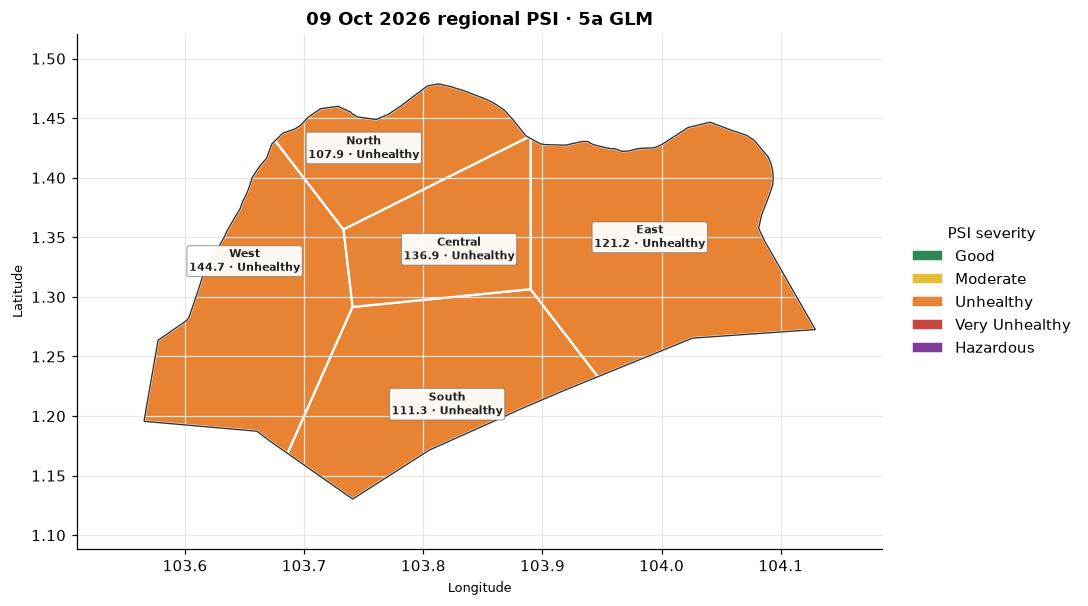

Region zones are approximate partitions of the main island, not official monitoring boundaries.


In [37]:
# Part 6 map: show selected-model PSI and severity inside approximate Singapore zones.
import geopandas as gpd
import requests
from IPython.display import display
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from shapely import voronoi_polygons
from shapely.geometry import MultiPoint, Point, shape

region_locations = {
    "North": (103.78, 1.43),
    "South": (103.83, 1.25),
    "East": (103.96, 1.35),
    "West": (103.65, 1.33),
    "Central": (103.82, 1.35),
}

response = requests.get(
    "https://nominatim.openstreetmap.org/search",
    params={"q": "Singapore", "format": "jsonv2", "polygon_geojson": 1, "limit": 1},
    headers={"User-Agent": "haze-monitoring-2026 regional PSI visualization"},
    timeout=30,
)
response.raise_for_status()
singapore_boundary = shape(response.json()[0]["geojson"])
main_island = max(singapore_boundary.geoms, key=lambda polygon: polygon.area)
voronoi_cells = voronoi_polygons(
    MultiPoint(list(region_locations.values())), extend_to=main_island.envelope
)

# Use selected-model PSI values for both zone fills and severity labels.
psi_by_region = forecast.set_index("region")["predicted_psi"]
severity_levels = ["Good", "Moderate", "Unhealthy", "Very Unhealthy", "Hazardous"]
severity_colors = ["#2d8a57", "#e2bd35", "#e78332", "#c84642", "#7d3c98"]
severity_cmap = ListedColormap(severity_colors)
severity_norm = BoundaryNorm([-0.5, 50.5, 100.5, 200.5, 300.5, 1000], severity_cmap.N)


def psi_severity(value):
    if value <= 50:
        return "Good"
    if value <= 100:
        return "Moderate"
    if value <= 200:
        return "Unhealthy"
    if value <= 300:
        return "Very Unhealthy"
    return "Hazardous"


zone_rows = []
for cell in voronoi_cells.geoms:
    clipped_cell = cell.intersection(main_island)
    if clipped_cell.is_empty:
        continue
    label_point = clipped_cell.representative_point()
    region = min(
        region_locations,
        key=lambda name: label_point.distance(Point(region_locations[name])),
    )
    value = float(psi_by_region.loc[region])
    zone_rows.append({
        "region": region,
        "predicted_psi": value,
        "severity": psi_severity(value),
        "geometry": clipped_cell,
    })

psi_zones = gpd.GeoDataFrame(zone_rows, geometry="geometry", crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(10, 7.5))
psi_zones.plot(
    ax=ax, column="predicted_psi", cmap=severity_cmap, norm=severity_norm,
    edgecolor="white", linewidth=1.5,
)
gpd.GeoSeries([main_island], crs="EPSG:4326").boundary.plot(
    ax=ax, color="#333333", linewidth=0.9,
)

# Put each label at a separated point inside its own zone, avoiding callouts outside the map.
label_candidates = {
    "North": (103.75, 1.425),
    "West": (103.65, 1.33),
    "Central": (103.83, 1.34),
    "East": (103.99, 1.35),
    "South": (103.82, 1.21),
}
for _, zone in psi_zones.iterrows():
    region = zone.region
    candidate = Point(label_candidates[region])
    label_point = candidate if zone.geometry.covers(candidate) else zone.geometry.representative_point()
    ax.text(
        label_point.x,
        label_point.y,
        f"{region}\n{zone.predicted_psi:.1f} · {zone.severity}",
        ha="center", va="center", fontsize=7, fontweight="bold", color="#222222",
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.94,
              "edgecolor": "#777777", "linewidth": 0.5},
        zorder=5,
    )

legend_handles = [
    Patch(facecolor=color, edgecolor="white", label=label)
    for label, color in zip(severity_levels, severity_colors)
]
min_longitude, min_latitude, max_longitude, max_latitude = main_island.bounds
longitude_margin = (max_longitude - min_longitude) * 0.10
latitude_margin = (max_latitude - min_latitude) * 0.12
ax.set_xlim(min_longitude - longitude_margin, max_longitude + longitude_margin)
ax.set_ylim(min_latitude - latitude_margin, max_latitude + latitude_margin)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{forecast_date:%d %b %Y} regional PSI · {forecast.selected_model.iloc[0]}")
ax.legend(handles=legend_handles, title="PSI severity", loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout()
fig.savefig(FIGS / "regional_psi_forecast_map.png", bbox_inches="tight", dpi=180)
display(fig)
plt.close(fig)
print("Region zones are approximate partitions of the main island, not official monitoring boundaries.")

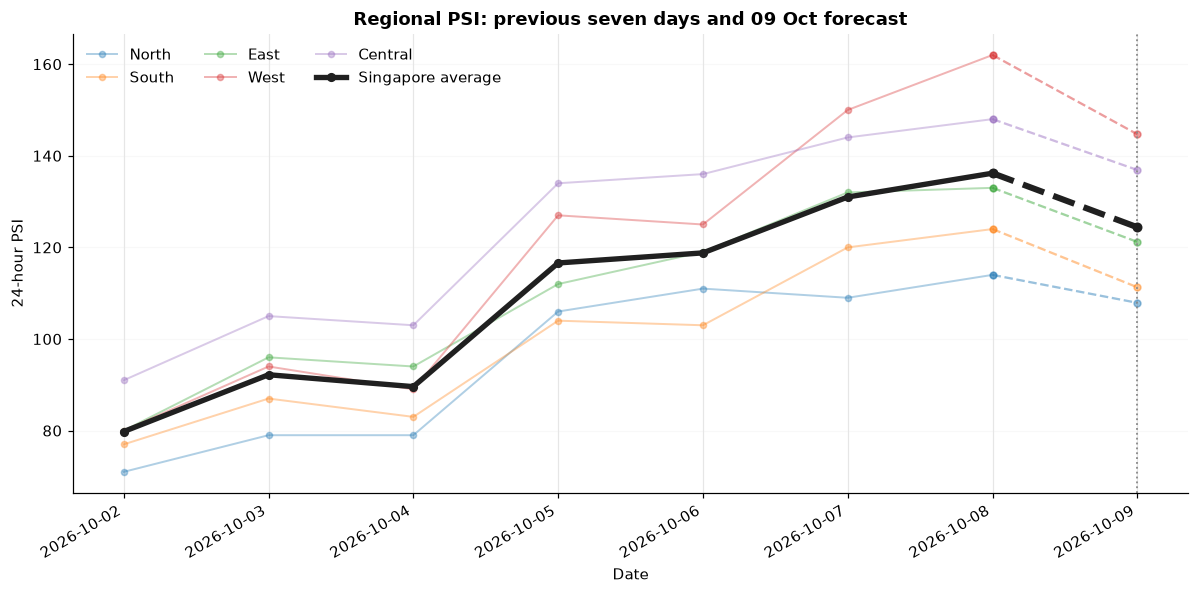

In [38]:
# Compare the selected-model forecast with the previous seven days in all regions.
plot_regions = ["North", "South", "East", "West", "Central"]
region_columns = [f"psi_{region.lower()}" for region in plot_regions]
history_week = df.sort_values("date").tail(7).copy()
plot_dates = list(history_week.date) + [forecast_date]

fig, ax = plt.subplots(figsize=(11, 5.5))
series_colors = dict(zip(plot_regions, plt.get_cmap("tab10").colors[:5]))
average_color = "#202020"

# Keep regional readings visible but subdued behind the Singapore-wide average.
for region, column in zip(plot_regions, region_columns):
    historical_values = history_week[column].to_numpy(dtype=float)
    predicted_value = float(
        forecast.loc[forecast.region == region, "predicted_psi"].iloc[0]
    )
    values = np.append(historical_values, predicted_value)
    color = series_colors[region]
    ax.plot(plot_dates[:7], values[:7], color=color, alpha=0.35, marker="o",
            markersize=4, linewidth=1.3, label=region)
    ax.plot(plot_dates[6:], values[6:], color=color, alpha=0.45, marker="o",
            markersize=4.5, linewidth=1.5, linestyle="--")

# Emphasize the daily mean of the five regions, including the selected-model forecast.
historical_average = history_week[region_columns].mean(axis=1).to_numpy(dtype=float)
forecast_average = float(forecast.predicted_psi.mean())
average_values = np.append(historical_average, forecast_average)
ax.plot(plot_dates[:7], average_values[:7], color=average_color, alpha=1.0,
        marker="o", markersize=5, linewidth=3.5, label="Singapore average", zorder=6)
ax.plot(plot_dates[6:], average_values[6:], color=average_color, alpha=1.0,
        marker="o", markersize=5.5, linewidth=4.0, linestyle="--", zorder=6)

ax.axvline(forecast_date, color=GREY, linestyle=":", linewidth=1.2)
ax.set_title(f"Regional PSI: previous seven days and {forecast_date:%d %b} forecast")
ax.set_xlabel("Date")
ax.set_ylabel("24-hour PSI")
ax.legend(ncol=3, frameon=False, loc="upper left")
ax.grid(True, axis="y", alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGS / "regional_psi_forecast_trend.png", bbox_inches="tight", dpi=180)
display(fig)
plt.close(fig)

**Forecast observations:** The table shows next-day PSI estimates from the selected lowest-RMSE model and the other three methods. The selection is based on five-fold historical time-series test performance, not a guarantee of tomorrow's conditions. Differences among estimates illustrate model uncertainty; interpret extreme-haze forecasts cautiously.

## 7. Findings, limitations and next steps

**Key findings**
- On identical five-fold chronological test windows, mean regional RMSE ranks **5a GLM 7.20**, **5d GAM 7.43**, **5b quadratic 7.87**, and **5c log-GLM 7.89 PSI points**.
- The GLM has the lowest test RMSE, though its residual diagnostics show upper-tail outliers and imperfect assumptions.
- The selected-model forecast and all four model estimates are saved to `data/processed/regional_psi_forecast.csv`.

**Limitations**
- Severe haze episodes are rare, so five-fold errors depend on which episodes appear in each test fold.
- The GAM smoothing parameter is fixed at 0.6; tuning it could change its performance.
- Historical reanalysis weather is used rather than an operational forecast; hotspot counts are approximate and cloud cover can hide detections.

**Next steps**
- Tune GAM smoothness and log-transform choices inside nested time-series validation.
- Test robust loss functions or a separate extreme-haze model.
- Validate on future haze seasons and add calibrated prediction intervals.